<a href="https://colab.research.google.com/github/Albedofan69420/FASHION-MNIST/blob/main/FASHION_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Introducción

Nuestra problemática principal se centra en la poseción de 60.000 imágenes de prendas diferentes en escala de grises sin categorizar. Si bien se comprende la existencia de diez clases diferentes para cada una (t-shirt, trouser, pullover, dress, coat, sandal, shirt, sneaker, bag, ankle boot), buscamos desarrollar un modelo de Deep Learning que sea capaz de clasificar correctamente cada una de las imágenes de pruebas existentes — en este caso, 10.000 imágenes provenientes del dataset en total —. Para poder cumplir con este objetivo establecido, se realizará un seguimiento completo de este proceso a través de este informe en conjunto con el código capaz de llevar esto a cabo.

#Carga y procesamiento de datos



In [1]:
# Importación de librerias necesarias para el desarrollo
from tensorflow import keras
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Cargar dataset Fashion-MNIST
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Mostrar dimensiones
print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: (60000, 28, 28) (60000,)
Test: (10000, 28, 28) (10000,)


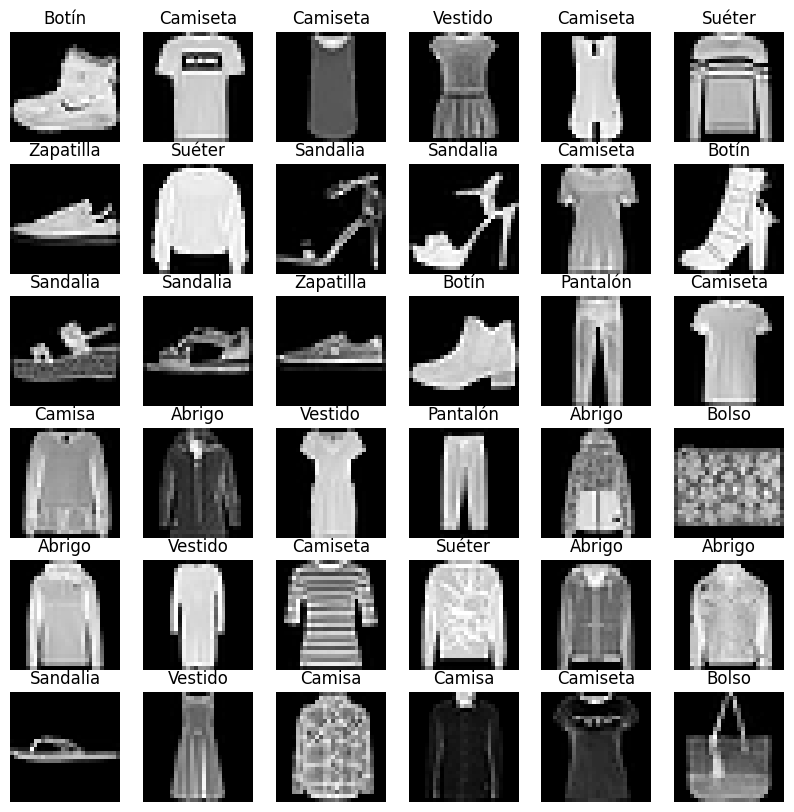

In [2]:
# Nombres de clases
clases = ['Camiseta', 'Pantalón', 'Suéter', 'Vestido', 'Abrigo',
          'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botín']

# Mostrar ejemplos
plt.figure(figsize=(10,10))
for i in range(36):
    plt.subplot(6,6,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(clases[y_train[i]])
    plt.axis('off')
plt.show()

In [3]:
# Normalizar los datos (0–255 → 0–1)
X_train = X_train / 255.0
X_test = X_test / 255.0

# Aplanar las imágenes (28x28 → 784)
X_train = X_train.reshape(-1, 28*28)
X_test = X_test.reshape(-1, 28*28)

# One-hot encoding de las etiquetas
Y_train = keras.utils.to_categorical(y_train, 10)
Y_test = keras.utils.to_categorical(y_test, 10)

# Verificamos dimensiones
print("X_train:", X_train.shape)
print("Y_train:", Y_train.shape)

X_train: (60000, 784)
Y_train: (60000, 10)


En la carga y pre-procresamiento de datos se hicieron los elementos descritos a continuación:

*   Se normalizaron los valores de los píxeles dividiéndolos por 255, con el objetivo de llevarlos a un rango entre 0 y 1. Esto mejora la estabilidad del entrenamiento y permite una mejor convergencia del modelo, escalando los valores para evitar números grandes.
*   Las imágenes de 28x28 píxeles fueron transformadas a vectores unidimensionales de 784 elementos, ya que las redes MLP requieren entradas en formato vectorial.
*   Las etiquetas fueron convertidas a formato one-hot encoding, lo que permite representar cada clase como un vector binario, facilitando el uso de la función de pérdida para clasificación multiclase.

#Definición del modelo

In [4]:
# seteamos los seed para números random:

np.random.seed(30)
tf.random.set_seed(30)

# Definimos las dimensiones de entrada y salida
N = X_train.shape[1]  # Dimensiones de entrada (784 píxeles)
C = Y_train.shape[1]  # Número de clases de salida (10 clases)

# Creación de la red:

h1 = 512
h2 = 256

model_dropout = keras.Sequential()
model_dropout.add(keras.layers.Dense(h1, input_dim=N, activation='relu'))
model_dropout.add(keras.layers.Dropout(0.3))
model_dropout.add(keras.layers.Dense(h2, activation='relu'))
model_dropout.add(keras.layers.Dropout(0.3))
model_dropout.add(keras.layers.Dense(h2, activation='relu'))
model_dropout.add(keras.layers.Dropout(0.3))
model_dropout.add(keras.layers.Dense(C, activation='softmax'))

model_dropout.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy', "Recall", tf.keras.metrics.F1Score(name='f1', average='macro')]
)

model_dropout.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 601,610 (2.29 MB)

 Trainable params: 601,610 (2.29 MB)

 Non-trainable params: 0 (0.00 B)

A continuación, se implementó una red neuronal multicapa (MLP) compuesta por tres capas densas. Las capas ocultas utilizan la función de activación ReLu, la cual permite una mejor propagación del gradiente y acelera el proceso de aprendizaje.

La capa de salida utiliza la función Softmax, que transforma las salidas en probabilidades, permitiendo clasificar las imágenes en una de las 10 categorías disponibles.

Se utilizó la función de pérdida categorical_crossentropy, adecuada para problemas de clasificación multiclase con etiquetas codificadas en formato one-hot encoding.

El optimizador seleccionado fue Adam, debido a su capacidad de ajustar automáticamente la tasa de aprendizaje y mejorar la convergencia del modelo.

#Entrenamiento y ajuste de hiperparámetros

In [5]:
history = model_dropout.fit(
    X_train, Y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - Recall: 0.7126 - accuracy: 0.7826 - f1: 0.7801 - loss: 0.6055 - val_Recall: 0.7834 - val_accuracy: 0.8331 - val_f1: 0.8307 - val_loss: 0.4574
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - Recall: 0.7933 - accuracy: 0.8364 - f1: 0.8347 - loss: 0.4540 - val_Recall: 0.8225 - val_accuracy: 0.8618 - val_f1: 0.8614 - val_loss: 0.3835
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - Recall: 0.8102 - accuracy: 0.8496 - f1: 0.8483 - loss: 0.4200 - val_Recall: 0.8225 - val_accuracy: 0.8597 - val_f1: 0.8604 - val_loss: 0.3795
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - Recall: 0.8196 - accuracy: 0.8564 - f1: 0.8554 - loss: 0.3975 - val_Recall: 0.8299 - val_accuracy: 0.8648 - val_f1: 0.8639 - val_loss: 0.3643
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - Recall: 0.8287 - accuracy: 0.8614 - f1: 0.8605 - loss: 0.3816 - val_Recall: 0.8353 - val_accuracy: 0.8704 - val_f1: 0.8706 - val_loss: 0.3639
Epoch 6/2

Se decidió utilizar las configuraciones mostradas con anterioridad con los siguientes objetivos en mente:

*   Epochs: se utilizaron 20 epochs con el propósito de comenzar con valores normales para comprender si el entrenamiento del modelo mejora continuamente, en lugar de iniciar con valores más altos, lo que puede dar paso al Overfitting del modelo.
*   Batch size: se inició con 32 batch debido a su centralidad dentro de los valores típicos utilizados en los batch comunmente. Al ser un valor central dentro de los demás valores, se comprende que con un valor más bajo pude haber más ruido, así como también se entiende que con un valor mucho más alto puede haber riesgo de overfitting.
*   Validation Split: se seleccionó un 20% del entrenamiento para la validación basándonos en las buenas prácticas de separación de 80/20, sin utilizar menos ni más al considerar el tamaño moderado del dataset y el equilibrio en la cantidad de datos necesarios para validar la capacidad de generalización del modelo.





#Evaluación del modelo

In [6]:
print(f"Train accuracy \u2248 {history.history['accuracy'][-1]*100:.1f}%")
print(f"Val accuracy \u2248 {history.history['val_accuracy'][-1]*100:.1f}%")

Train accuracy ≈ 89.2%
Val accuracy ≈ 88.6%


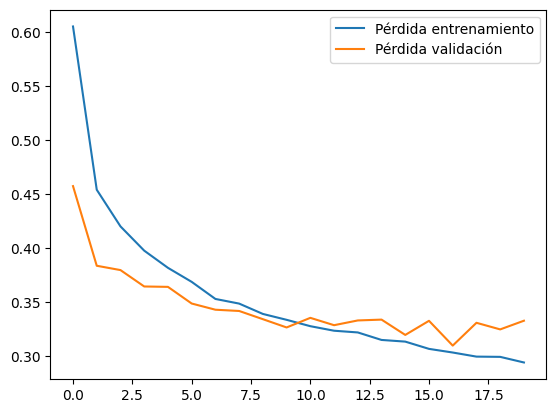

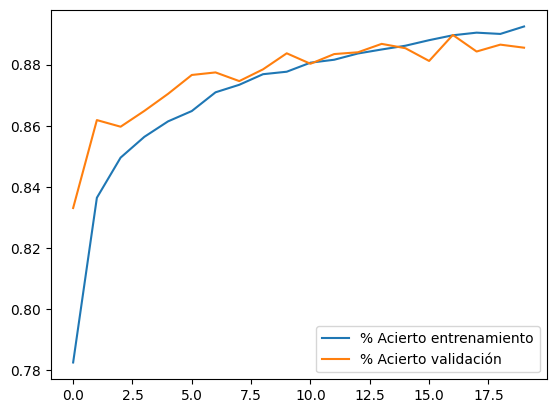

In [7]:
# Gráficamos las perdidas y los aciertos por cada época

plt.plot(history.history['loss'], label='Pérdida entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida validación')
plt.legend()
plt.show()

plt.plot(history.history['accuracy'], label='% Acierto entrenamiento')
plt.plot(history.history['val_accuracy'], label='% Acierto validación')
plt.legend()
plt.show()

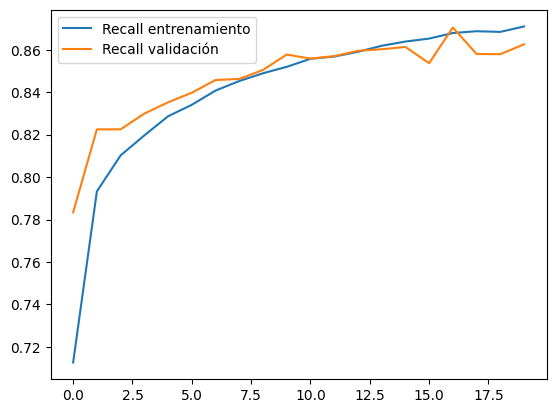

In [8]:
plt.plot(history.history['Recall'], label='Recall entrenamiento')
plt.plot(history.history['val_Recall'], label='Recall validación')
plt.legend()
plt.show()

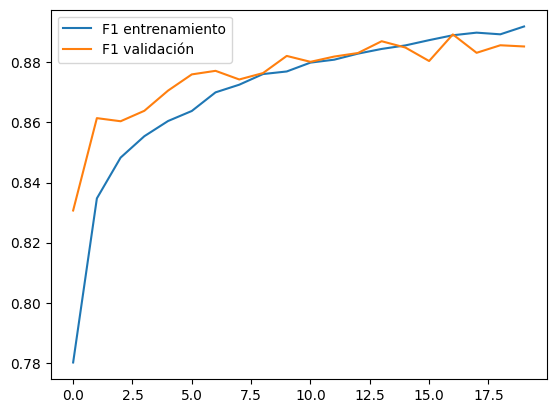

In [9]:
plt.plot(history.history['f1'], label='F1 entrenamiento')
plt.plot(history.history['val_f1'], label='F1 validación')
plt.legend()
plt.show()

> **Gráfico de perdida:** Hola

> **Gráfico de Acierto:** hola

#Análisis y mejora del modelo

A continuación se detallarán los cambios impuestos en el desarrollo del modelo para obtención de mejores resultados en el entrenamiento.

*   Inicialmente se trabajó un modelo sin algún tipo de regularización o implementación extra. Se presentó un claro caso de Overfitting, donde el modelo memorizó los datos y no logró aprender patrones para la posterior validación.

Train accuracy ≈ 93.7%
Val accuracy ≈ 87.9%

*   Se decidió modificar la cantidad de Épocas durante el entrenamiento del modelo. Se aumentaron 10 Épocas en base a las 20 anteriores (20 -> 30), así como también se quitaron 10 (20 -> 10). Si bien cambiaron los resultados, los gráficos representaron un Overfitting mayor y un aprendizaje más bajo que en los entrenamientos pasados, por lo que es mejor mantener 20 épocas para este.

Train accuracy ≈ 94.9%
Val accuracy ≈ 88.5%

Train accuracy ≈ 96.2%
Val accuracy ≈ 88.3%

*   Posteriormente se buscó trabajar con la técnica de regularización Dropout, permitiendonos desactivar neuronas al azar para mejorar la robustez de aprendizaje del modelo. Se nota una mejoría clara en el aprendizaje de este, demostrando una alta capacidad de aprendizaje y una menor pérdida entre los valores validados.

Train accuracy ≈ 89.2%
Val accuracy ≈ 88.6%


#Conclusiones